# Inspect Processed ROS2 Dataset

这个 notebook 用来检查 `sync_from_bag_and_audio.py` 或 `sync_audio_with_extracted_data.py` 生成后的同步数据。

重点检查：

- `lio_odom.npz` / `lio_robo_odom.npz` 是否存在
- odom 的 `x,y,z` 轨迹是否正常
- audio / image / odom / metadata 样本数量是否大致对齐
- odom 时间戳和同步时间差是否合理


In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

## 1. 设置数据路径

把 `DATASET_DIR` 改成你的同步结果目录，例如：

```text
synced_dataset/bag_001
```


In [17]:
DATASET_DIR = Path("../synced_dataset/clock3")
DATASET_DIR = DATASET_DIR.expanduser().resolve()
print(DATASET_DIR)
print("exists:", DATASET_DIR.exists())

/home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3
exists: True


## 2. 检查目录结构和样本数量

In [18]:
modalities = ["audio", "color", "depth", "lio_odom", "lio_robo_odom", "metadata"]

for name in modalities:
    d = DATASET_DIR / name
    if not d.exists():
        print(f"{name:14s}: missing")
        continue
    files = sorted([p for p in d.iterdir() if p.is_file()])
    print(f"{name:14s}: {len(files)} files")
    print("  first:", files[0].name if files else None)
    print("  last :", files[-1].name if files else None)

manifest_path = DATASET_DIR / "dataset_manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    print("\nmanifest samples:", len(manifest.get("samples", [])))
    print("sample_rate:", manifest.get("sample_rate"))
    print("segment_sec:", manifest.get("segment_sec"))
    print("hop_sec:", manifest.get("hop_sec"))
else:
    manifest = None
    print("\nNo dataset_manifest.json found")

audio         : 310 files
  first: 000000.wav
  last : 000309.wav
color         : 310 files
  first: 000000.png
  last : 000309.png
depth         : 310 files
  first: 000000.png
  last : 000309.png
lio_odom      : 310 files
  first: 000000.npy
  last : 000309.npy
lio_robo_odom : 310 files
  first: 000000.npy
  last : 000309.npy
metadata      : 310 files
  first: 000000.json
  last : 000309.json

manifest samples: 310
sample_rate: 16000
segment_sec: 1.0
hop_sec: 0.2


## 3. 读取 odom NPZ

`data` 的字段顺序由 `fields` 给出，默认是：

```text
px, py, pz, qx, qy, qz, qw, linear_x, linear_y, linear_z, angular_x, angular_y, angular_z
```


In [19]:
def load_odom_npz(dataset_dir, name="lio_robo_odom"):
    path = dataset_dir / f"{name}.npz"
    if not path.exists():
        raise FileNotFoundError(path)
    odom = np.load(path, allow_pickle=False)
    fields = [str(x) for x in odom["fields"]]
    data = odom["data"]
    timestamps_ns = odom["timestamps_ns"]
    diff_ns = odom["diff_ns"]
    sample_ids = odom["sample_ids"]
    return {
        "path": path,
        "fields": fields,
        "data": data,
        "timestamps_ns": timestamps_ns,
        "diff_ns": diff_ns,
        "sample_ids": sample_ids,
    }

odom_name = "lio_robo_odom"  # 可改为 "lio_odom"
odom = load_odom_npz(DATASET_DIR, odom_name)

print("path:", odom["path"])
print("fields:", odom["fields"])
print("data shape:", odom["data"].shape)
print("timestamps shape:", odom["timestamps_ns"].shape)
print("max diff sec:", odom["diff_ns"].max() / 1e9 if len(odom["diff_ns"]) else None)

path: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3/lio_robo_odom.npz
fields: ['px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw', 'linear_x', 'linear_y', 'linear_z', 'angular_x', 'angular_y', 'angular_z']
data shape: (310, 13)
timestamps shape: (310,)
max diff sec: 0.005543228


## 4. 提取位置 XYZ

In [20]:
fields = odom["fields"]
data = odom["data"]

idx = {name: fields.index(name) for name in fields}
x = data[:, idx["px"]]
y = data[:, idx["py"]]
z = data[:, idx["pz"]]

print("x range:", x.min(), x.max())
print("y range:", y.min(), y.max())
print("z range:", z.min(), z.max())

x range: -3.3225107192993164 3.08036732673645
y range: -0.8293409943580627 1.5280570983886719
z range: -0.2172718346118927 -0.13815172016620636


## 5. XY 平面轨迹

通常先看 XY 平面，最容易判断机器人走的路径是否合理。

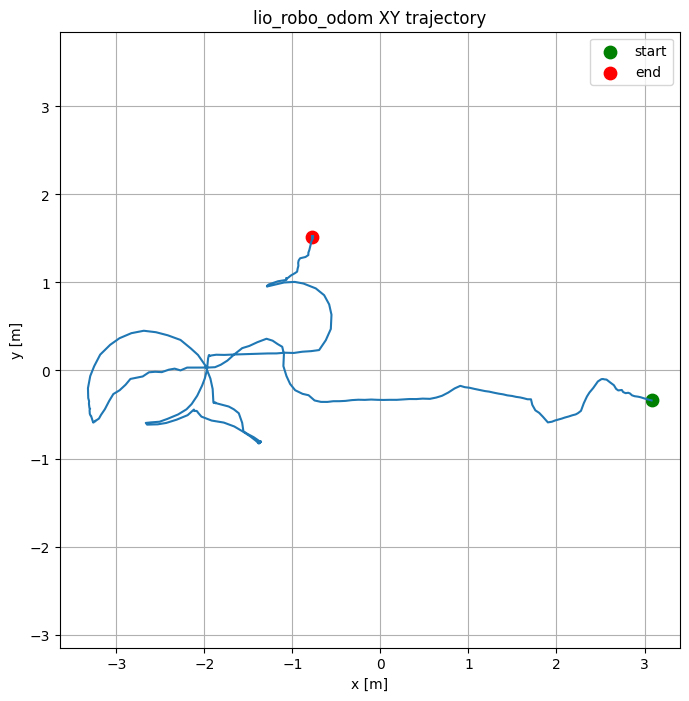

In [21]:
plt.figure(figsize=(8, 8))
plt.plot(x, y, linewidth=1.5)
plt.scatter(x[0], y[0], c="green", s=80, label="start")
plt.scatter(x[-1], y[-1], c="red", s=80, label="end")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"{odom_name} XY trajectory")
plt.legend()
plt.show()

## 6. XYZ 三维轨迹

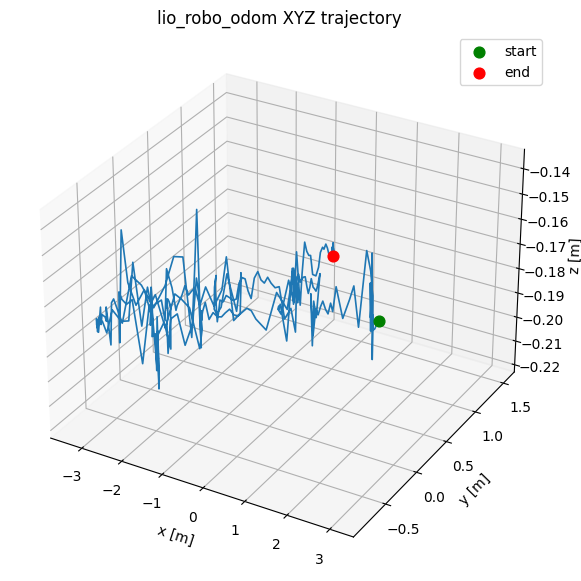

In [22]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z, linewidth=1.2)
ax.scatter(x[0], y[0], z[0], c="green", s=60, label="start")
ax.scatter(x[-1], y[-1], z[-1], c="red", s=60, label="end")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"{odom_name} XYZ trajectory")
ax.legend()
plt.show()

## 7. 位置随样本编号变化

如果轨迹有跳变，这个图通常更容易定位异常点。

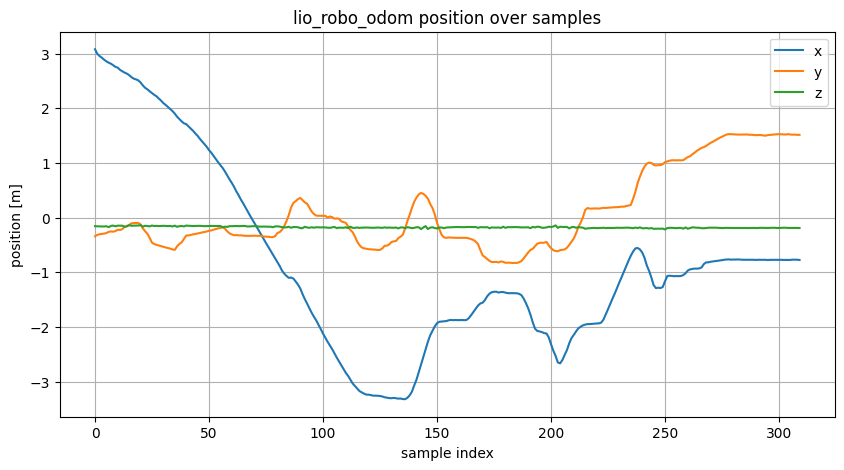

In [23]:
sample_idx = np.arange(len(x))

plt.figure(figsize=(10, 5))
plt.plot(sample_idx, x, label="x")
plt.plot(sample_idx, y, label="y")
plt.plot(sample_idx, z, label="z")
plt.xlabel("sample index")
plt.ylabel("position [m]")
plt.title(f"{odom_name} position over samples")
plt.legend()
plt.show()

## 8. 检查同步误差

`diff_ns` 是同步样本时间和最近 odom 时间之间的差值。默认处理脚本中 `--max-diff-sec` 是 0.2 秒。

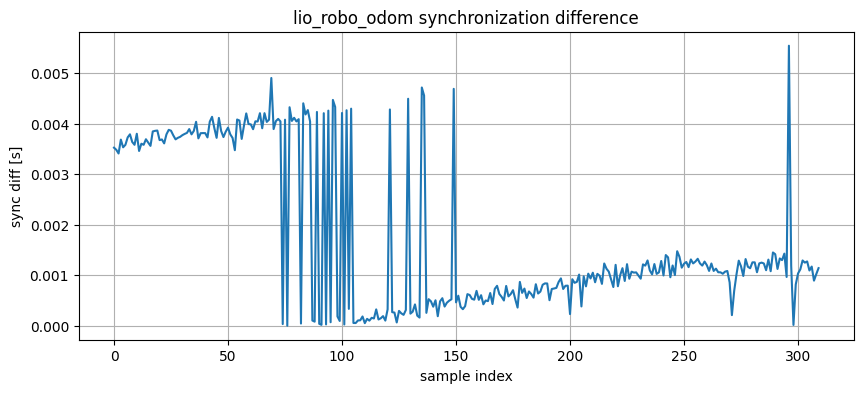

mean diff sec: 0.0017710660193548389
max diff sec : 0.005543228


In [24]:
diff_sec = odom["diff_ns"] / 1e9

plt.figure(figsize=(10, 4))
plt.plot(diff_sec)
plt.xlabel("sample index")
plt.ylabel("sync diff [s]")
plt.title(f"{odom_name} synchronization difference")
plt.show()

print("mean diff sec:", diff_sec.mean() if len(diff_sec) else None)
print("max diff sec :", diff_sec.max() if len(diff_sec) else None)

## 9. 同时比较 `/lio/odom` 和 `/lio/robo/odom`

如果两个文件都存在，可以把它们画在同一张图里。

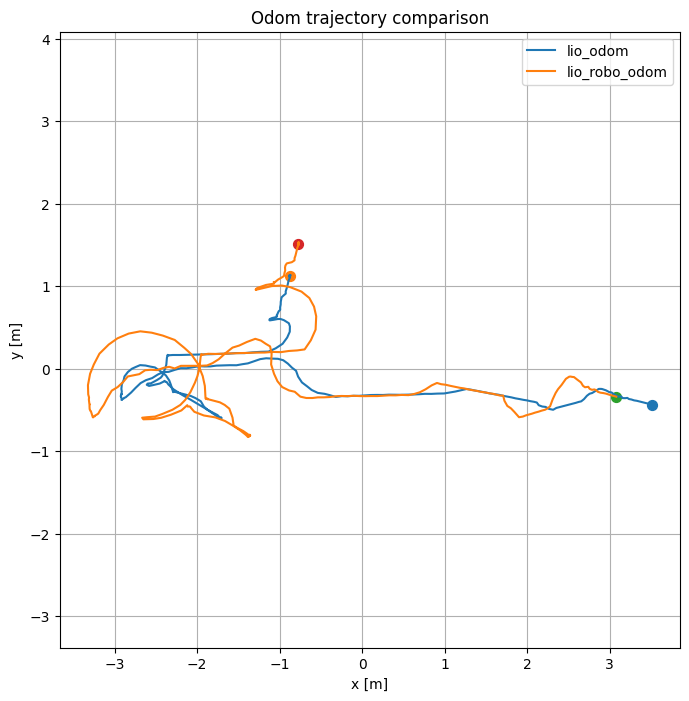

In [25]:
def xy_from_odom(name):
    item = load_odom_npz(DATASET_DIR, name)
    fields = item["fields"]
    data = item["data"]
    return data[:, fields.index("px")], data[:, fields.index("py")]

plt.figure(figsize=(8, 8))

for name in ["lio_odom", "lio_robo_odom"]:
    path = DATASET_DIR / f"{name}.npz"
    if not path.exists():
        print(f"skip missing {path}")
        continue
    xx, yy = xy_from_odom(name)
    plt.plot(xx, yy, label=name)
    plt.scatter(xx[0], yy[0], s=50)
    plt.scatter(xx[-1], yy[-1], s=50)

plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Odom trajectory comparison")
plt.legend()
plt.show()

## 10. 可视化 DOA

这一部分读取 `compute_doa_from_odom.py` 生成的 `doa_*.npz`，在 XY 轨迹上标出若干采样点的 DOA。

- 蓝色箭头：机器人头方向，也就是麦克风/机器人 body `+x` 方向投影到水平面
- 橙色箭头：从机器人当前位置指向 target 的方向
- 文字：`heading_target_yaw_signed_deg`，也就是从蓝色箭头转到橙色箭头的水平有符号夹角

默认只标少量点，避免文字和轨迹重叠。

In [26]:
def load_doa_npz(dataset_dir, odom_name="lio_odom", output_prefix="doa"):
    path = dataset_dir / f"{output_prefix}_{odom_name}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run compute_doa_from_odom.py first, for example:\n"
            f"python data_processing/compute_doa_from_odom.py --dataset {dataset_dir} --odom {odom_name}"
        )
    item = np.load(path, allow_pickle=False)
    fields = [str(x) for x in item["fields"]]
    return {
        "path": path,
        "fields": fields,
        "data": item["data"],
        "sample_ids": item["sample_ids"],
        "timestamps_ns": item["timestamps_ns"],
    }


doa_odom_name = "lio_odom"  # 可改成 "lio_robo_odom"
doa = load_doa_npz(DATASET_DIR, doa_odom_name)
doa_idx = {name: doa["fields"].index(name) for name in doa["fields"]}
doa_data = doa["data"]

robot_x = doa_data[:, doa_idx["robot_x"]]
robot_y = doa_data[:, doa_idx["robot_y"]]
target_x = doa_data[:, doa_idx["target_x"]]
target_y = doa_data[:, doa_idx["target_y"]]
heading_x = doa_data[:, doa_idx["heading_world_x"]]
heading_y = doa_data[:, doa_idx["heading_world_y"]]
target_vec_x = doa_data[:, doa_idx["target_vector_world_x"]]
target_vec_y = doa_data[:, doa_idx["target_vector_world_y"]]
yaw_signed = doa_data[:, doa_idx["heading_target_yaw_signed_deg"]]

print("path:", doa["path"])
print("fields:", doa["fields"])
print("data shape:", doa_data.shape)
print("yaw range:", yaw_signed.min(), yaw_signed.max())

path: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3/doa_lio_odom.npz
fields: ['robot_x', 'robot_y', 'source_odom_x', 'source_odom_y', 'target_x', 'target_y', 'target_vector_world_x', 'target_vector_world_y', 'heading_world_x', 'heading_world_y', 'distance_xy', 'robot_heading_world_deg', 'target_azimuth_world_deg', 'heading_target_yaw_signed_deg', 'heading_target_yaw_abs_deg']
data shape: (310, 15)
yaw range: -177.85458003716835 174.9323957647286


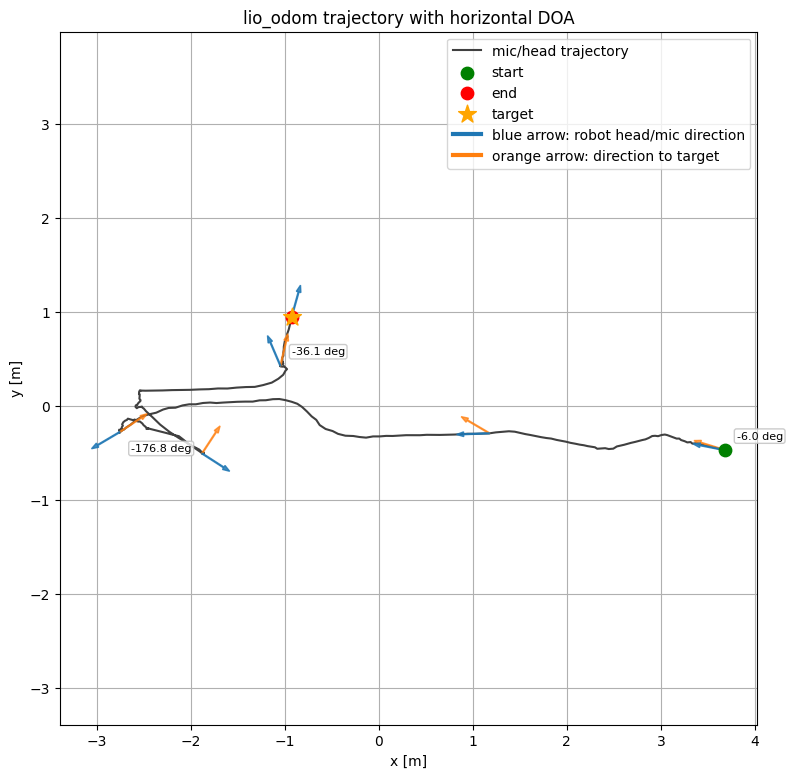

In [27]:
def normalize_xy(u, v):
    norm = np.hypot(u, v)
    if norm == 0:
        return 0.0, 0.0
    return u / norm, v / norm


num_markers = 6        # 图上标多少个点；越小越稀疏
arrow_length = 0.35    # 箭头长度，单位 m；如果轨迹尺度大，可以调大
label_every = 2        # 每几个 marker 标一次角度；越大文字越少

marker_indices = np.linspace(0, len(robot_x) - 1, min(num_markers, len(robot_x)), dtype=int)

plt.figure(figsize=(9, 9))
plt.plot(robot_x, robot_y, color="0.25", linewidth=1.5, label="mic/head trajectory")
plt.scatter(robot_x[0], robot_y[0], c="green", s=80, label="start", zorder=5)
plt.scatter(robot_x[-1], robot_y[-1], c="red", s=80, label="end", zorder=5)
plt.scatter(target_x[-1], target_y[-1], c="orange", marker="*", s=180, label="target", zorder=6)
plt.plot([], [], color="tab:blue", linewidth=3, label="blue arrow: robot head/mic direction")
plt.plot([], [], color="tab:orange", linewidth=3, label="orange arrow: direction to target")

for k, i in enumerate(marker_indices):
    hx, hy = normalize_xy(heading_x[i], heading_y[i])
    tx, ty = normalize_xy(target_vec_x[i], target_vec_y[i])

    plt.arrow(
        robot_x[i], robot_y[i],
        hx * arrow_length, hy * arrow_length,
        width=0.01,
        head_width=0.05,
        length_includes_head=True,
        color="tab:blue",
        alpha=0.85,
        zorder=4,
    )
    plt.arrow(
        robot_x[i], robot_y[i],
        tx * arrow_length, ty * arrow_length,
        width=0.01,
        head_width=0.05,
        length_includes_head=True,
        color="tab:orange",
        alpha=0.75,
        zorder=3,
    )

    if k % label_every == 0:
        offset = (8, 8) if (k // label_every) % 2 == 0 else (8, -14)
        plt.annotate(
            f"{yaw_signed[i]:.1f} deg",
            xy=(robot_x[i], robot_y[i]),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "0.75", "alpha": 0.8},
        )

plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"{doa_odom_name} trajectory with horizontal DOA")
plt.legend()
plt.show()

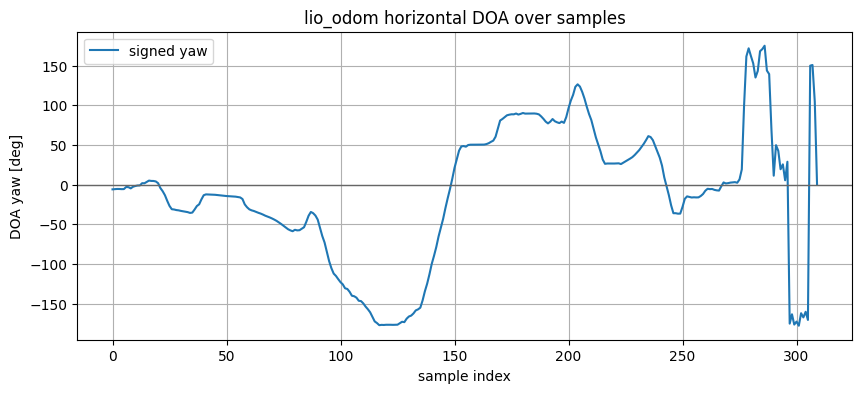

mean abs yaw: 65.35788913437904
max abs yaw : 177.85458003716835


In [28]:
sample_axis = np.arange(len(yaw_signed))

plt.figure(figsize=(10, 4))
plt.plot(sample_axis, yaw_signed, label="signed yaw")
plt.axhline(0.0, color="0.4", linewidth=1.0)
plt.xlabel("sample index")
plt.ylabel("DOA yaw [deg]")
plt.title(f"{doa_odom_name} horizontal DOA over samples")
plt.legend()
plt.show()

print("mean abs yaw:", np.mean(np.abs(yaw_signed)))
print("max abs yaw :", np.max(np.abs(yaw_signed)))

## 9. 每个 seq 的 DOA 突变检查与轨迹可视化

这一节按 clock/seq 检查相邻样本之间的 DOA 是否有明显跳变。因为 DOA 是角度，差值使用环形角度差，也就是会正确处理 `179° -> -179°` 这种跨边界情况。

图里包含：

- 机器人/mic 轨迹
- 最终目标点
- 稀疏采样的机器人朝向箭头
- 稀疏采样的目标方向箭头
- DOA 曲线和相邻 DOA 跳变量


In [35]:
JUMP_THRESHOLD_DEG = 30.0
ARROW_STRIDE = 20

def circular_diff_deg(current, previous):
    return (current - previous + 180.0) % 360.0 - 180.0

def load_doa_sequence(dataset_dir):
    rows = []
    for path in sorted((dataset_dir / DOA_DIR_NAME).glob("*.npy")):
        row = np.load(path).astype(np.float64)
        if len(row) < 16:
            continue
        rows.append({
            "sample_id": path.stem,
            "robot_x": row[0],
            "robot_y": row[1],
            "target_x": row[4],
            "target_y": row[5],
            "target_vector_x": row[6],
            "target_vector_y": row[7],
            "heading_x": row[8],
            "heading_y": row[9],
            "distance_xy": row[10],
            "yaw_signed": row[14],
            "yaw_abs": row[15],
        })
    return rows

def summarize_doa_jumps(dataset_dir, threshold_deg=JUMP_THRESHOLD_DEG):
    rows = load_doa_sequence(dataset_dir)
    if len(rows) < 2:
        print(f"{dataset_dir.name}: not enough DOA samples")
        return rows, np.array([]), []
    yaw = np.array([row["yaw_signed"] for row in rows], dtype=np.float64)
    jumps = circular_diff_deg(yaw[1:], yaw[:-1])
    jump_abs = np.abs(jumps)
    bad_indices = np.where(jump_abs > threshold_deg)[0] + 1

    print(f"\n{dataset_dir.name}")
    print(f"  samples: {len(rows)}")
    print(f"  yaw min/mean/max: {yaw.min():.2f} / {yaw.mean():.2f} / {yaw.max():.2f} deg")
    print(f"  adjacent jump mean/p95/max abs: {jump_abs.mean():.2f} / {np.percentile(jump_abs, 95):.2f} / {jump_abs.max():.2f} deg")
    print(f"  jumps > {threshold_deg:.1f} deg: {len(bad_indices)}")
    for idx in bad_indices[:10]:
        print(
            f"    {rows[idx - 1]['sample_id']} -> {rows[idx]['sample_id']}: "
            f"{yaw[idx - 1]:7.2f} -> {yaw[idx]:7.2f}, "
            f"jump={jumps[idx - 1]:7.2f} deg, "
            f"dist={rows[idx]['distance_xy']:.2f} m"
        )
    return rows, jumps, bad_indices

jump_results = {}
for dataset_dir in dataset_dirs:
    jump_results[dataset_dir.name] = summarize_doa_jumps(dataset_dir)



clock2
  samples: 125
  yaw min/mean/max: -177.35 / 1.45 / 179.36 deg
  adjacent jump mean/p95/max abs: 4.89 / 18.06 / 156.53 deg
  jumps > 30.0 deg: 6
    000110 -> 000111:    7.90 -> -144.61, jump=-152.52 deg, dist=0.00 m
    000111 -> 000112: -144.61 ->  176.16, jump= -39.23 deg, dist=0.01 m
    000116 -> 000117:  179.36 ->  -24.11, jump= 156.53 deg, dist=0.00 m
    000118 -> 000119:  -17.48 ->   16.88, jump=  34.36 deg, dist=0.00 m
    000122 -> 000123:   27.86 ->  -37.51, jump= -65.37 deg, dist=0.01 m
    000123 -> 000124:  -37.51 ->    0.00, jump=  37.51 deg, dist=0.00 m

clock3
  samples: 310
  yaw min/mean/max: -177.85 / -10.54 / 174.93 deg
  adjacent jump mean/p95/max abs: 6.08 / 15.43 / 156.06 deg
  jumps > 30.0 deg: 10
    000276 -> 000277:   19.15 ->   99.95, jump=  80.80 deg, dist=0.01 m
    000277 -> 000278:   99.95 ->  161.36, jump=  61.41 deg, dist=0.02 m
    000286 -> 000287:  174.93 ->  143.65, jump= -31.28 deg, dist=0.00 m
    000288 -> 000289:  139.15 ->   69.17, j

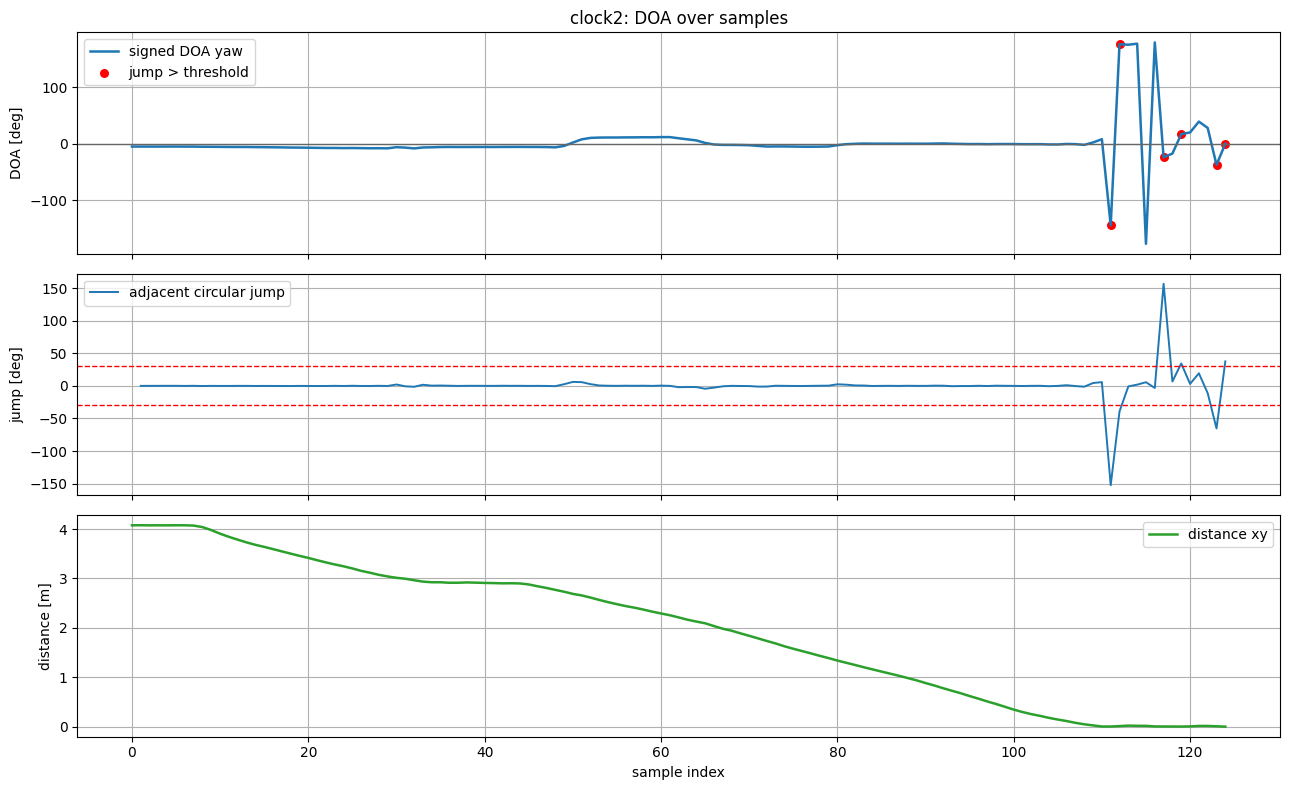

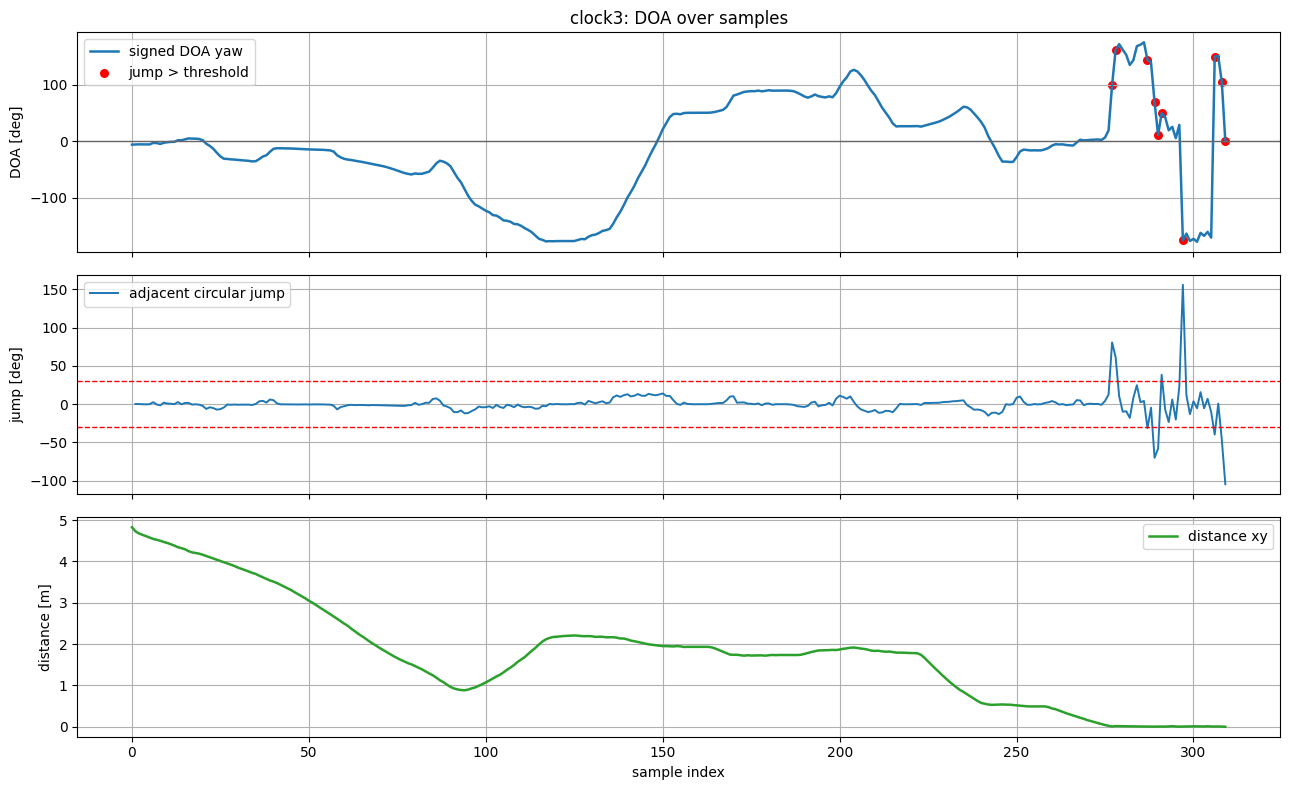

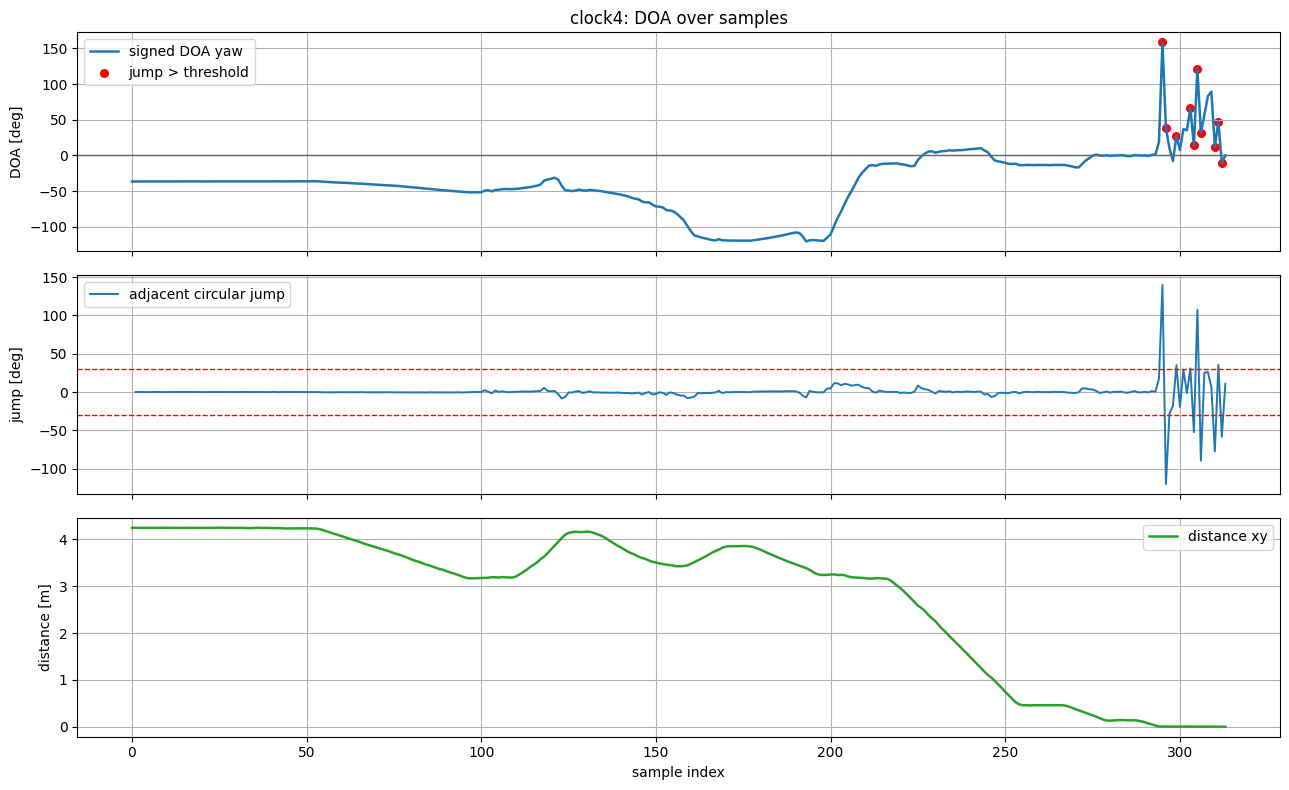

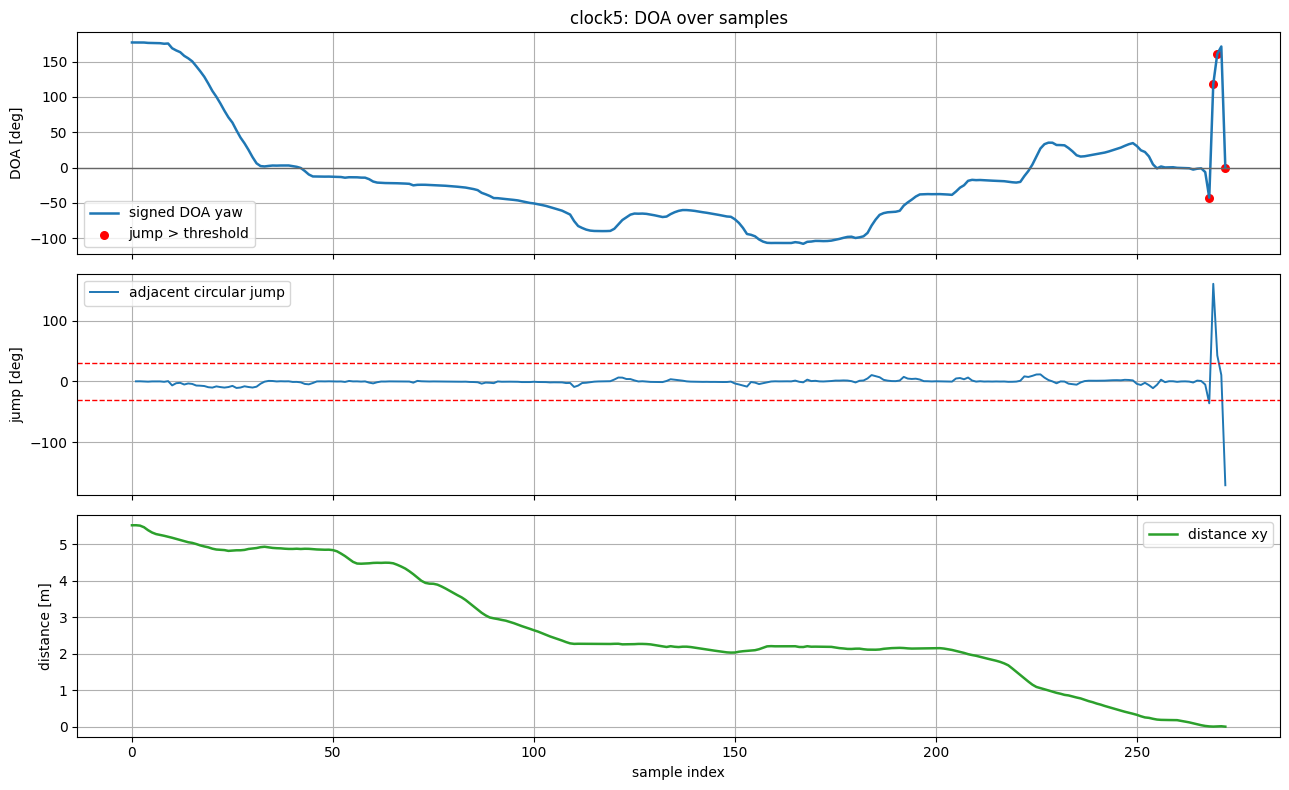

In [36]:
def plot_doa_timeseries(dataset_dir, rows, jumps, bad_indices):
    if not rows:
        return
    sample_axis = np.arange(len(rows))
    yaw = np.array([row["yaw_signed"] for row in rows], dtype=np.float64)
    distance = np.array([row["distance_xy"] for row in rows], dtype=np.float64)

    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(sample_axis, yaw, linewidth=1.8, label="signed DOA yaw")
    if len(bad_indices):
        axes[0].scatter(bad_indices, yaw[bad_indices], color="red", s=30, label="jump > threshold")
    axes[0].axhline(0.0, color="0.4", linewidth=1.0)
    axes[0].set_ylabel("DOA [deg]")
    axes[0].set_title(f"{dataset_dir.name}: DOA over samples")
    axes[0].legend()

    if len(jumps):
        axes[1].plot(sample_axis[1:], jumps, linewidth=1.4, label="adjacent circular jump")
        axes[1].axhline(JUMP_THRESHOLD_DEG, color="red", linestyle="--", linewidth=1.0)
        axes[1].axhline(-JUMP_THRESHOLD_DEG, color="red", linestyle="--", linewidth=1.0)
    axes[1].set_ylabel("jump [deg]")
    axes[1].legend()

    axes[2].plot(sample_axis, distance, color="tab:green", linewidth=1.8, label="distance xy")
    axes[2].set_ylabel("distance [m]")
    axes[2].set_xlabel("sample index")
    axes[2].legend()
    plt.tight_layout()
    plt.show()

for dataset_dir in dataset_dirs:
    rows, jumps, bad_indices = jump_results[dataset_dir.name]
    plot_doa_timeseries(dataset_dir, rows, jumps, bad_indices)


In [ ]:
def normalized_vectors(xs, ys, scale=0.35):
    vec = np.stack([xs, ys], axis=1).astype(np.float64)
    norm = np.linalg.norm(vec, axis=1, keepdims=True)
    norm = np.maximum(norm, 1e-8)
    return vec / norm * scale

def plot_trajectory_with_doa(dataset_dir, rows, bad_indices, stride=ARROW_STRIDE):
    if not rows:
        return
    x = np.array([row["robot_x"] for row in rows], dtype=np.float64)
    y = np.array([row["robot_y"] for row in rows], dtype=np.float64)
    yaw = np.array([row["yaw_signed"] for row in rows], dtype=np.float64)
    target_x = float(rows[0]["target_x"])
    target_y = float(rows[0]["target_y"])
    heading_x = np.array([row["heading_x"] for row in rows], dtype=np.float64)
    heading_y = np.array([row["heading_y"] for row in rows], dtype=np.float64)
    target_vec_x = np.array([row["target_vector_x"] for row in rows], dtype=np.float64)
    target_vec_y = np.array([row["target_vector_y"] for row in rows], dtype=np.float64)

    fig, ax = plt.subplots(figsize=(8, 8))
    points = ax.scatter(x, y, c=yaw, cmap="twilight", vmin=-180, vmax=180, s=18, label="mic trajectory")
    ax.plot(x, y, color="0.55", linewidth=1.0, alpha=0.7)
    ax.scatter([x[0]], [y[0]], c="limegreen", s=80, marker="o", edgecolor="black", label="start")
    ax.scatter([x[-1]], [y[-1]], c="black", s=80, marker="s", label="end")
    ax.scatter([target_x], [target_y], c="red", s=120, marker="*", label="target(final)")

    arrow_idx = np.arange(0, len(rows), max(1, stride))
    heading_vec = normalized_vectors(heading_x[arrow_idx], heading_y[arrow_idx], scale=0.28)
    target_vec = normalized_vectors(target_vec_x[arrow_idx], target_vec_y[arrow_idx], scale=0.38)
    ax.quiver(x[arrow_idx], y[arrow_idx], heading_vec[:, 0], heading_vec[:, 1], angles="xy", scale_units="xy", scale=1, color="tab:blue", width=0.004, label="heading")
    ax.quiver(x[arrow_idx], y[arrow_idx], target_vec[:, 0], target_vec[:, 1], angles="xy", scale_units="xy", scale=1, color="tab:red", width=0.003, alpha=0.8, label="target direction")

    if len(bad_indices):
        ax.scatter(x[bad_indices], y[bad_indices], facecolors="none", edgecolors="yellow", s=150, linewidth=2.0, label="DOA jump")
        for idx in bad_indices[:8]:
            ax.annotate(rows[idx]["sample_id"], (x[idx], y[idx]), textcoords="offset points", xytext=(5, 5), fontsize=8)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(f"{dataset_dir.name}: trajectory colored by DOA")
    ax.legend(loc="best")
    cbar = plt.colorbar(points, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("signed DOA yaw [deg]")
    plt.tight_layout()
    plt.show()

for dataset_dir in dataset_dirs:
    rows, jumps, bad_indices = jump_results[dataset_dir.name]
    plot_trajectory_with_doa(dataset_dir, rows, bad_indices)


In [37]:
import numpy as np

In [42]:
x = np.load("/home/kemove/yyz/audio-nav/ws_col/tmp/clock3/distance_lio_odom/000001.npy")

In [43]:
x

array([4.72817076, 4.72834818])